# 1. Persiapan Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('chip_prices.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year_month  405 non-null    object 
 1   year        405 non-null    int64  
 2   product     405 non-null    object 
 3   currency    405 non-null    object 
 4   unit        405 non-null    object 
 5   price       405 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 19.1+ KB


,year_month,year,product,currency,unit,price
0,2014-01,2014,DRAM_DDR4_8Gb,USD,USD/chip,4.36
1,2014-02,2014,DRAM_DDR4_8Gb,USD,USD/chip,4.50
2,2014-03,2014,DRAM_DDR4_8Gb,USD,USD/chip,4.39
3,2014-04,2014,DRAM_DDR4_8Gb,USD,USD/chip,3.97
4,2014-05,2014,DRAM_DDR4_8Gb,USD,USD/chip,4.02


# 2. Analisis Data

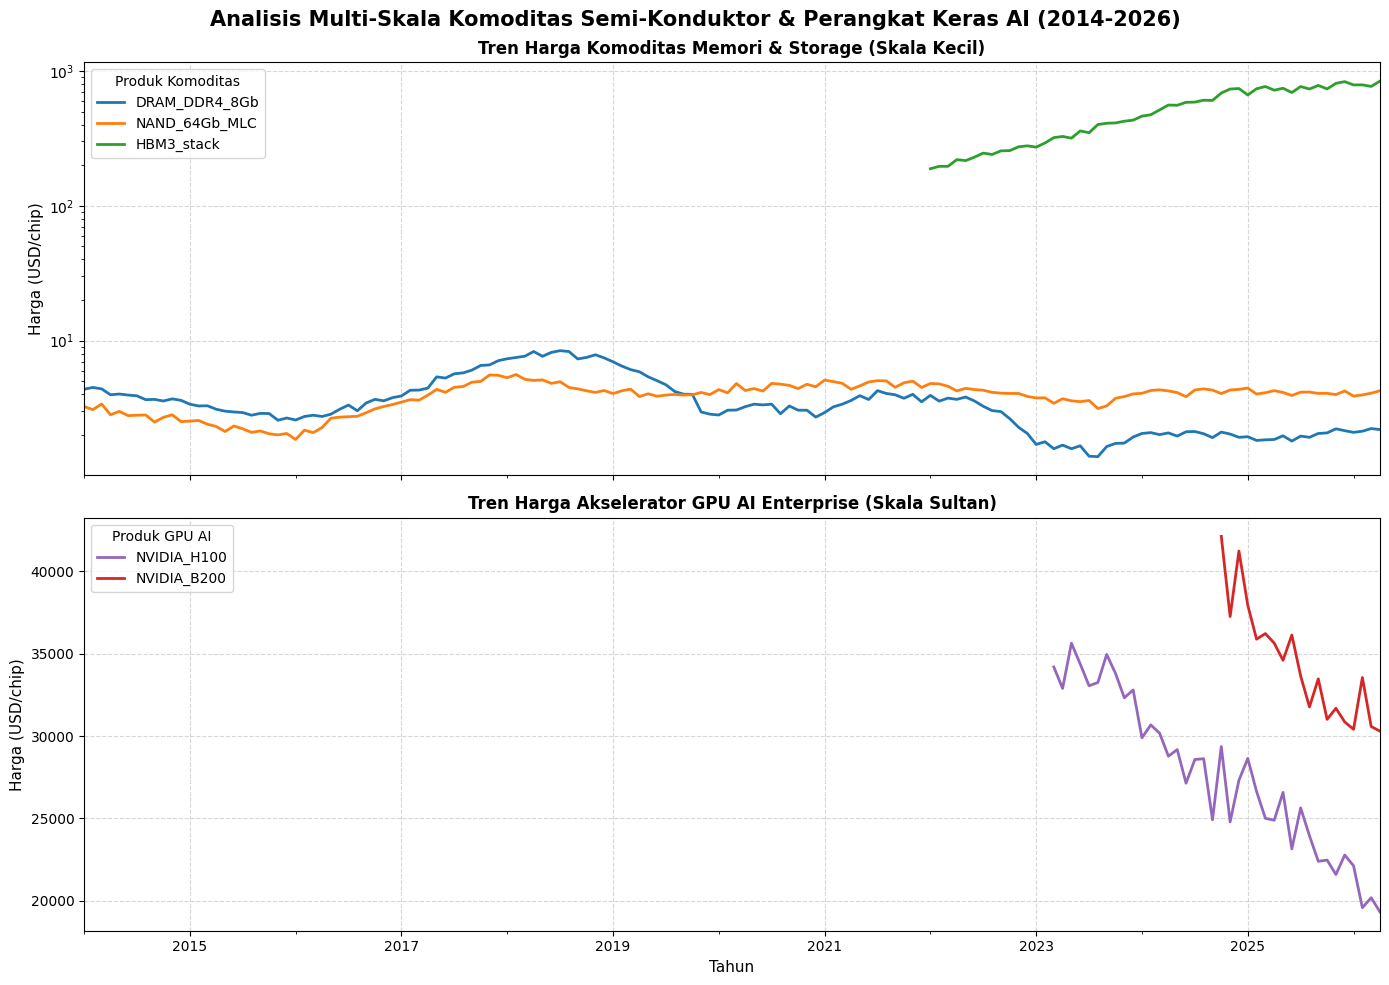

In [14]:
import matplotlib.pyplot as plt

df = df.sort_values('year_month')
df_pivot = df.pivot(index='year_month', columns='product', values='price')

commodity_cols = ['DRAM_DDR4_8Gb', 'NAND_64Gb_MLC', 'HBM3_stack']
gpu_cols = ['NVIDIA_H100', 'NVIDIA_B200']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- GRAFIK 1: KELOMPOK CHIP KOMODITAS (ATAS) ---
df_pivot[commodity_cols].plot(ax=ax1, linewidth=2)
ax1.set_title('Tren Harga Komoditas Memori & Storage (Skala Kecil)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Harga (USD/chip)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_yscale('log')
ax1.legend(title='Produk Komoditas', loc='upper left')

# --- GRAFIK 2: KELOMPOK GPU AI ENTERPRISE (BAWAH) ---
df_pivot[gpu_cols].plot(ax=ax2, linewidth=2, color=['#9467bd', '#d62728'])
ax2.set_title('Tren Harga Akselerator GPU AI Enterprise (Skala Sultan)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Harga (USD/chip)', fontsize=11)
ax2.set_xlabel('Tahun', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title='Produk GPU AI', loc='upper left')

plt.suptitle('Analisis Multi-Skala Komoditas Semi-Konduktor & Perangkat Keras AI (2014-2026)',
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()